### Importing Relevant Packages

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statsmodels.graphics.tsaplots as sgt 
import statsmodels.tsa.stattools as sts 
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns


### Loading and Transforming the Data

In [80]:
raw_csv_data = pd.read_csv("Index2018.csv") 


In [81]:
raw_csv_data.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [83]:
df_comp=raw_csv_data.copy() # getting a copy of the raw dataset
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date", inplace=True) # formatting the dataset as per we want !!
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [84]:
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26




### Removing Surplus Data

In [85]:
df_comp['market_value']=df_comp.spx

In [86]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df_train, df_test = df_comp.iloc[:size], df_comp.iloc[size:] # created train and test dataframes for fitting models!!

### White Noise

`we generate random numbers which are normally distributed having same length as our df_train and we will make it as `
`one column inside the df_train dataframe and then we can compare the spx data(market_value) and white noise data`       

In [87]:
wn = np.random.normal(loc=df_train.market_value.mean(), scale = df_train.market_value.std(), size = len(df_train))

**here we generated random normally distributed numbers having mean and variance similar to our market_value data**
`since each number is generated around the values they do not have exact means and variances but similar/very close`

In [88]:
df_train['wn'] = wn

C:\Users\Pradhuman\AppData\Local\Temp\ipykernel_10952\2767877954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['wn'] = wn


In [89]:
df_train.describe()

,market_value,wn
count,5021.000000,5021.000000
mean,1091.651926,1081.961396
std,292.559287,292.828864
min,438.920000,79.801493
25%,914.620000,880.371745
50%,1144.650000,1080.499535
75%,1316.280729,1274.891990
max,1570.252238,2083.542425


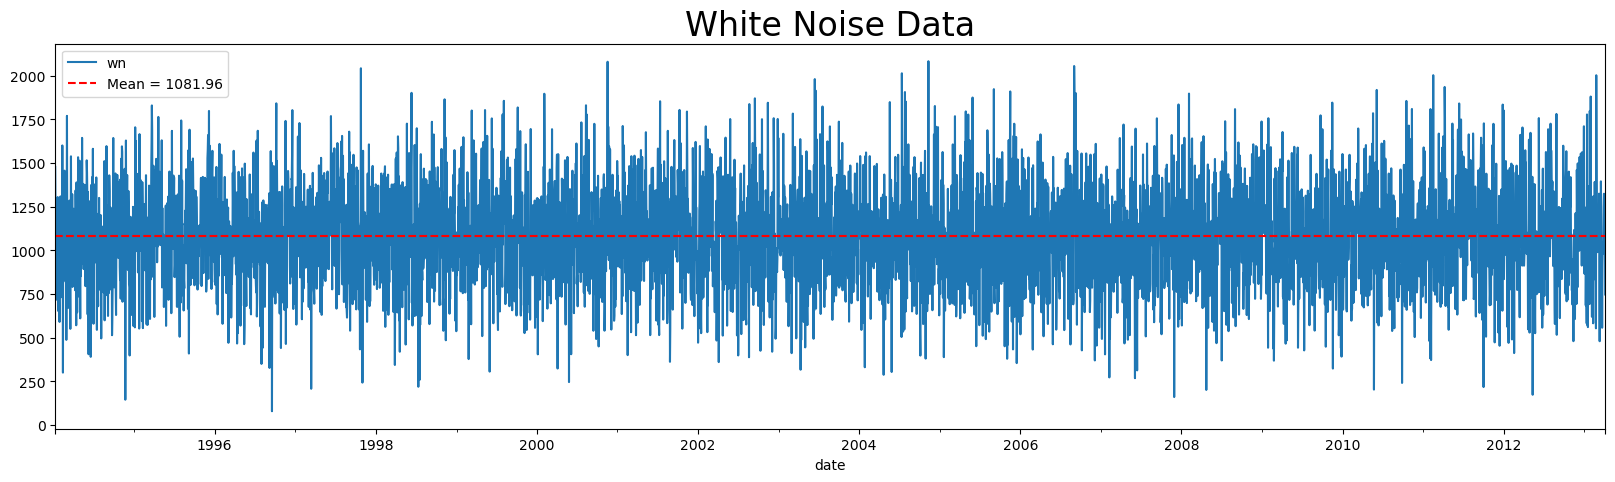

In [90]:
# Plotting line graph of each data value over the years
mean_val = df_train.wn.mean()
df_train.wn.plot(figsize=(20,5))
plt.title('White Noise Data',size=24)
plt.axhline(mean_val, linestyle='--',color='r', label=f"Mean = {mean_val:.2f}")
plt.legend()
plt.show()

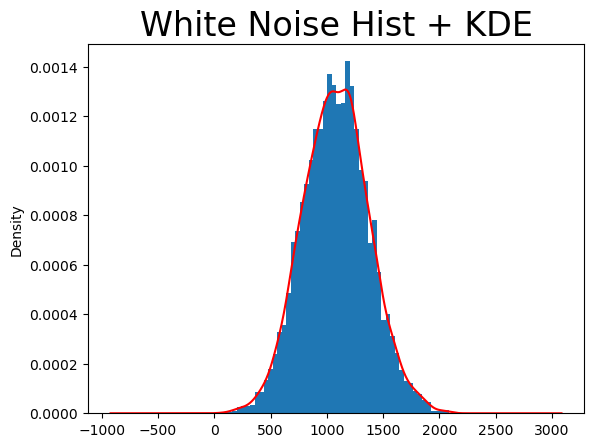

In [91]:
df_train['wn'].plot(kind='hist', bins=50, density=True)
df_train.wn.plot(kind='kde',color='r')
plt.title('White Noise Hist + KDE',size=24)
plt.show()

**Plotting Hist + KDE and line plot for Market Value data**

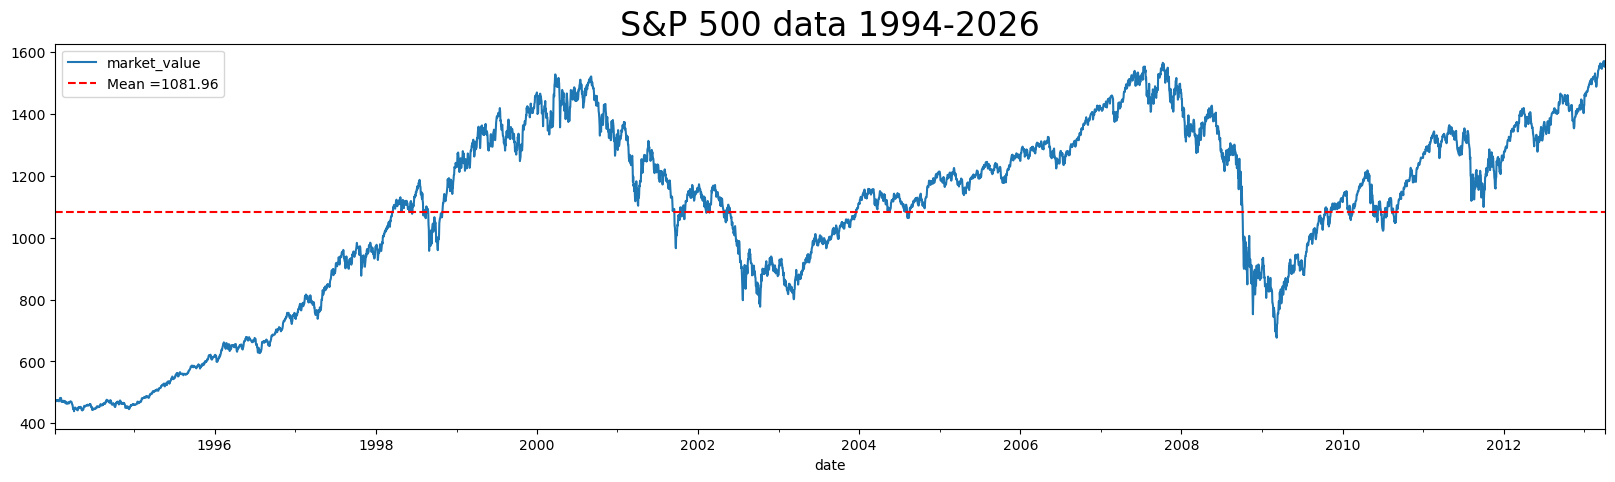

In [92]:
mean_val_mv = df_train.market_value.mean()
df_train.market_value.plot(figsize=(20,5))
plt.title('S&P 500 data 1994-2026',size=24)
plt.axhline(mean_val, linestyle="--", color='r', label = f'Mean ={mean_val:.2f}')
plt.legend()
plt.show()

### Random Walk

In [93]:
rw = pd.read_csv('RandWalk.csv')

In [94]:
rw.date = pd.to_datetime(rw.date, dayfirst=True) # To datetime and in yyyy/mm/dd

In [95]:
# setting date as indexes 
rw.set_index('date',inplace=True)

In [96]:
rw.asfreq('b')
rw.price = rw.price.ffill() # filling the missing prices with previous day prices

In [97]:
rw.isna().sum() # checking if there is any nan values left

price    0
dtype: int64

In [98]:
rw.head() # And we are done!!

,price
date,
1994-01-07,1122.139662
1994-01-08,1135.238562
1994-01-09,1109.897831
1994-01-10,1080.347860
1994-01-11,1082.095245


In [ ]:
# Adding this data as a new column inside the df_train dataframe
df_train['rw'] = rw.price
df_train.describe()

In [101]:
df_train.head()

,market_value,wn,rw
date,,,
1994-01-07,469.90,1478.656367,1122.139662
1994-01-10,475.27,1183.536606,1080.347860
1994-01-11,474.13,934.079389,1082.095245
1994-01-12,474.17,718.095599,1083.639265
1994-01-13,472.47,1281.971236,1067.146255


**This is how we generate a random data of random walk**                                                                
`previously we just got the data pre prepared!!`

In [ ]:
import numpy as np
import pandas as pd

n = len(df_comp)

np.random.seed(42)
white_noise = np.random.normal(0, 1, n)

random_walk = np.cumsum(white_noise)

rw_series = pd.Series(random_walk, index=df_comp.index)

**Plotting the data for comparison**

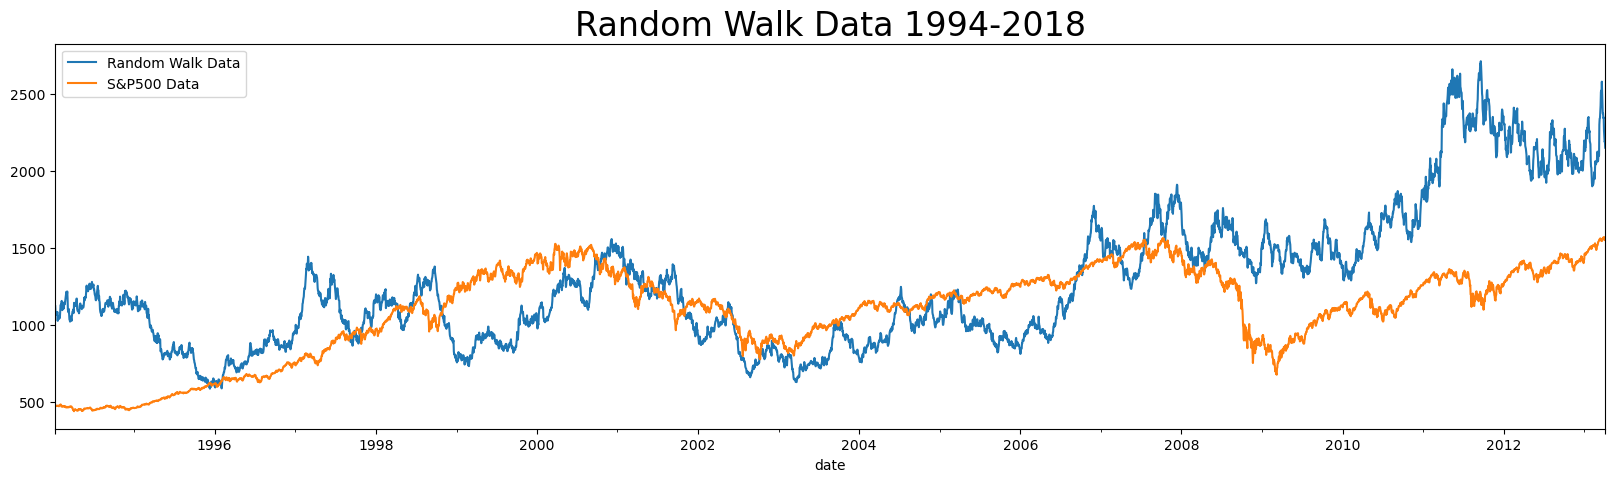

In [108]:
df_train.rw.plot(figsize=(20,5), label='Random Walk Data')
df_train.market_value.plot(label='S&P500 Data')
plt.title('Random Walk Data 1994-2018',size=24)
plt.legend()
plt.show()

`This data actually look very similar to the S&P 500 Data`

### Stationarity

In [111]:
# Applying Dickey-Fuller Test to check the Stationarity of the Time Series Data on S&P 500
sts.adfuller(df_train.market_value)

(np.float64(-1.7369847452352436),
 np.float64(0.4121645696770623),
 18,
 5002,
 {'1%': np.float64(-3.431658008603046),
  '5%': np.float64(-2.862117998412982),
  '10%': np.float64(-2.567077669247375)},
 np.float64(39904.880607487445))

`The Answer is obvious -> since the data is obviously autocorrelated that's why we reject the cannot reject the hypothesis -> The Time Series has Non- Stationarity`

In [112]:
# Checking the same for White Noise data
sts.adfuller(df_train.wn)

(np.float64(-71.50962509623768),
 0.0,
 0,
 5020,
 {'1%': np.float64(-3.431653316130827),
  '5%': np.float64(-2.8621159253018247),
  '10%': np.float64(-2.5670765656497516)},
 np.float64(70820.2136885191))

`we see that p value is zero and Number of lags is also zero implies that the Time Series has Stationarity`

In [113]:
# Checking for random Walk
sts.adfuller(df_train.rw)

(np.float64(-1.3286073927689719),
 np.float64(0.6159849181617385),
 24,
 4996,
 {'1%': np.float64(-3.4316595802782865),
  '5%': np.float64(-2.8621186927706463),
  '10%': np.float64(-2.567078038881065)},
 np.float64(46299.333497595144))

`We cannot reject the null hypothesis for Random Walk also -> The Time Series cannot assume Stationarity here` 

### Seasonality

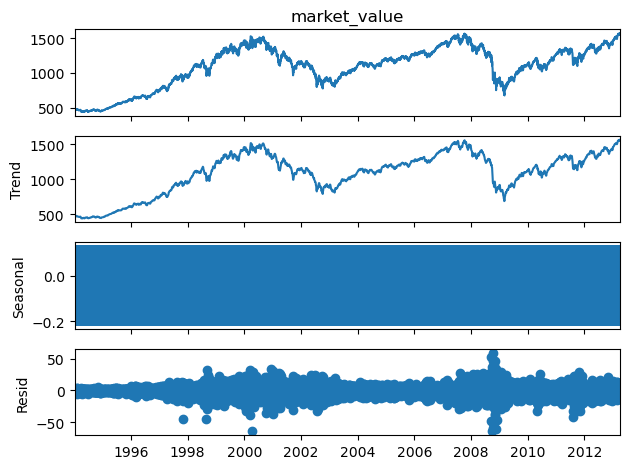

In [114]:
# Cehcking additive Naive Decomposition -> to look for trends, seasonality and residuals
s_dec_additive = seasonal_decompose(df_train.market_value, model = 'additive')
s_dec_additive.plot()
plt.show()

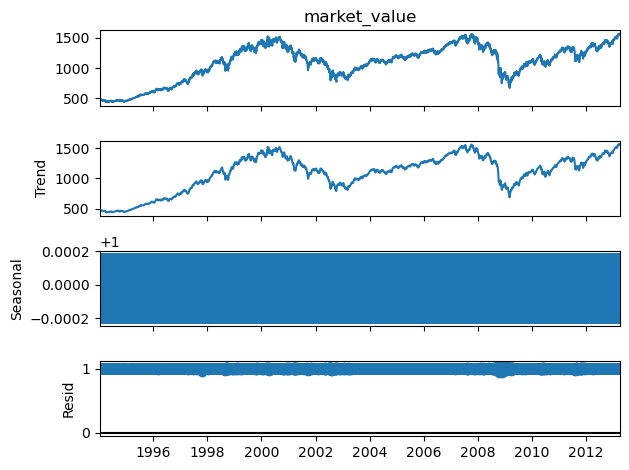

In [118]:
# Creating multiplicative decomposition
s_dec_mul = seasonal_decompose(df_train.market_value, model = 'multiplicative')
s_dec_mul.plot()
plt.show()

### ACF

In [ ]:
# We will plot the auto correlation plot for a data b/w the current values and their lagged version
import statsmodels.graphics.tsaplots as sgt

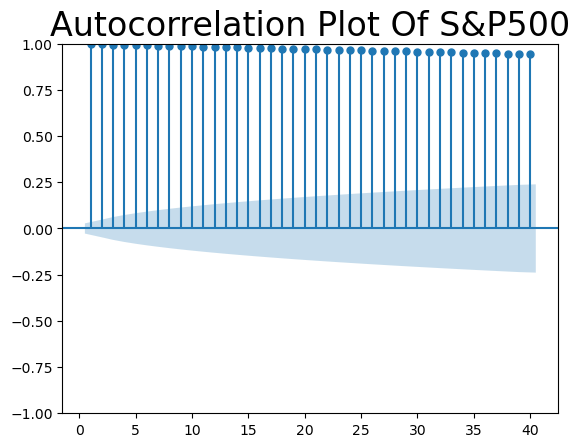

In [122]:
sgt.plot_acf(df_train.market_value, lags = 40, zero=False)
plt.title('Autocorrelation Plot Of S&P500',size=24)
plt.show()

**It is known that the prices in finance are non- stationary and that is why we cannot use models to predict**
**whereas if we find the returns instead of prices, then they are stationary and we can use models**

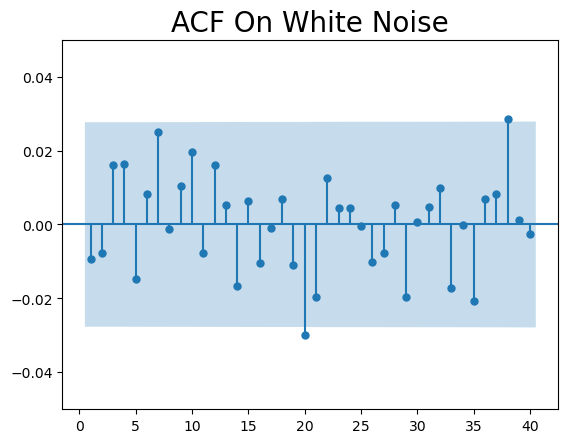

In [131]:
# Checking ACF On White Noise Data
sgt.plot_acf(df_train.wn,lags=40,zero=False)
plt.title("ACF On White Noise",size=20)
plt.ylim(-.05,0.05)
plt.show()

`ACF of White noise is inside the confidence band suggesting the data being Stationary`

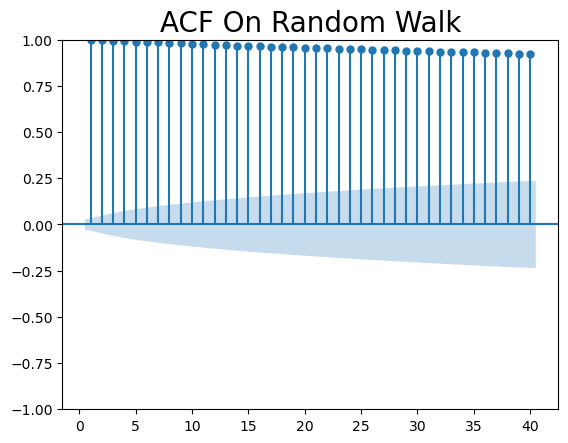

In [133]:
# Checking ACF For random walk
sgt.plot_acf(df_train.rw,lags=40,zero=False)
plt.title("ACF On Random Walk",size=20)
plt.show()

### PACF

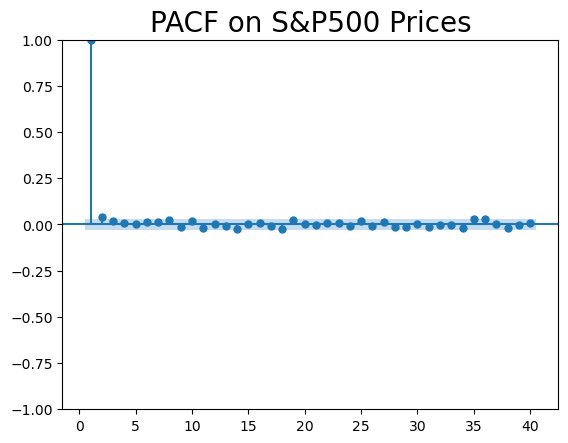

In [ ]:
# Plotting Parital Autocorrelation Function on S&P500 Prices Data
sgt.plot_pacf(df_train.market_value,lags=40,zero=False)
plt.title("PACF on S&P500 Prices",size=20)
plt.show()

`Since PACF tells us the autocorrelation b/w current value and kth lagged value directly (no lags in between)`             
`That is why 1st lag correlation is same as ACF but after 3-4 lags, the PACF correlation is inside the confidence band`
`showing that there is almost no correlation b/w the values.`

#### The positive and negative behaviour of the correlation after some lags is just pure randomness and there is no as such pattern involved.